# 机器学习入门


## 第一章：机器学习基本理论

### 1-1 特征工程常用方法

####  1-1-1 相关系数法

In [ ]:
import pandas as pd

advertising = pd.read_csv("data/advertising.csv")
advertising.drop(advertising.columns[0], axis=1, inplace=True)
advertising.dropna(inplace=True)
X = advertising.drop("Sales", axis=1)
y = advertising["Sales"]
# 计算皮尔逊相关系数
print(X.corrwith(y, method="pearson"))
# TV           0.782224
# Radio        0.576223
# Newspaper    0.228299
# dtype: float64
#使用pandas.DataFrame.corr(method="pearson")计算皮尔逊相关系数矩阵。
import seaborn as sns
import matplotlib.pyplot as plt

# 计算皮尔逊相关系数矩阵
corr_matrix = advertising.corr(method="pearson")
# 可视化热力图
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

![20260606000601](https://lin01-image-1373317342.cos.ap-beijing.myqcloud.com/20260606000601.png)

![20260606000635](https://lin01-image-1373317342.cos.ap-beijing.myqcloud.com/20260606000635.png)

In [ ]:
import pandas as pd

# 每周学习时长
X = [[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]]
# 数学考试成绩
y = [55, 65, 70, 75, 85, 50, 60, 72, 80, 58]
# 计算斯皮尔曼相关系数
X = pd.DataFrame(X)
y = pd.Series(y)
print(X.corrwith(y, method="spearman"))
# 0.987879

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

n_samples = 1000
# 第1个主成分方向
component1 = np.random.normal(0, 1, n_samples)
# 第2个主成分方向
component2 = np.random.normal(0, 0.2, n_samples)
# 第3个方向（噪声，方差较小）
noise = np.random.normal(0, 0.1, n_samples)
# 构造3维数据
X = np.vstack([component1 - component2, component1 + component2, component2 + noise]).T

# 标准化
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# 应用PCA，将3维数据降维到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)

# 可视化
# 转换前的3维数据可视化
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c="g")
ax1.set_title("Before PCA (3D)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.set_zlabel("Feature 3")
# 转换后的2维数据可视化
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c="g")
ax2.set_title("After PCA (2D)")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
plt.show()

#### 1-1-2 损失函数

预测结果f(X)，而真实的结果（标签）记为Y。f(X) 和Y之间可能会有偏差，我们就用一个损失函数（loss function）来度量预测偏差的程度，记作 L(Y,f(X))。
![20260606174559](https://lin01-image-1373317342.cos.ap-beijing.myqcloud.com/20260606174559.png)

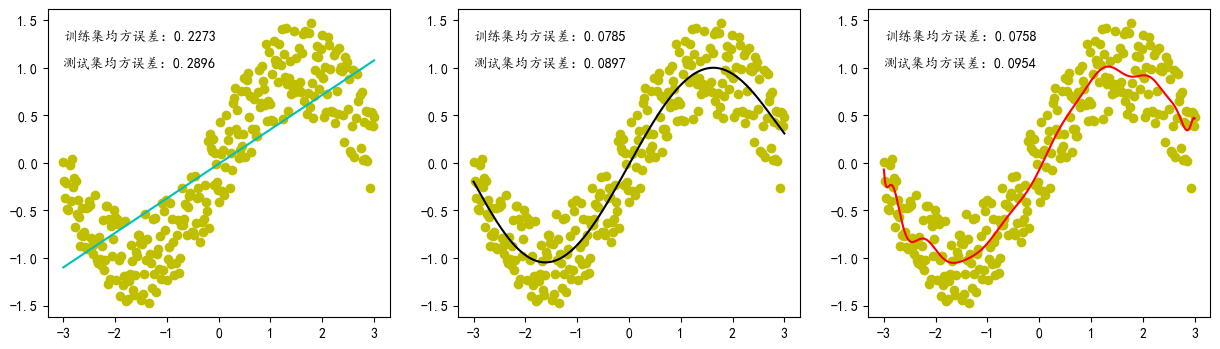

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

plt.rcParams["font.sans-serif"] = ["KaiTi"]
plt.rcParams["axes.unicode_minus"] = False

def polynomial(x, degree):
    return np.hstack([x**i for i in range(1, degree + 1)])

# 生成随机数据
X = np.linspace(-3, 3, 300).reshape(-1, 1)
y = np.sin(X) + np.random.uniform(-0.5, 0.5, 300).reshape(-1, 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(X, y, "yo")
ax[1].plot(X, y, "yo")
ax[2].plot(X, y, "yo")

# 划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建线性回归模型
model = LinearRegression()

# 欠拟合
x_train1 = x_train
x_test1 = x_test
model.fit(x_train1, y_train)# 模型训练
y_pred1 = model.predict(x_test1)# 预测
ax[0].plot(np.array([[-3], [3]]), model.predict(np.array([[-3], [3]])), "c")# 绘制曲线
ax[0].text(-3, 1, f"测试集均方误差：{mean_squared_error(y_test, y_pred1):.4f}")
ax[0].text(-3, 1.3, f"训练集均方误差：{mean_squared_error(y_train, model.predict(x_train1)):.4f}")

# 恰好拟合
x_train2 = polynomial(x_train, 5)
x_test2 = polynomial(x_test, 5)
model.fit(x_train2, y_train)# 模型训练
y_pred2 = model.predict(x_test2)# 预测
ax[1].plot(X, model.predict(polynomial(X, 5)), "k")# 绘制曲线
ax[1].text(-3, 1, f"测试集均方误差：{mean_squared_error(y_test, y_pred2):.4f}")
ax[1].text(-3, 1.3, f"训练集均方误差：{mean_squared_error(y_train, model.predict(x_train2)):.4f}")

# 过拟合
x_train3 = polynomial(x_train, 20)
x_test3 = polynomial(x_test, 20)
model.fit(x_train3, y_train)# 模型训练
y_pred3 = model.predict(x_test3)# 预测
ax[2].plot(X, model.predict(polynomial(X, 20)), "r")# 绘制曲线
ax[2].text(-3, 1, f"测试集均方误差：{mean_squared_error(y_test, y_pred3):.4f}")
ax[2].text(-3, 1.3, f"训练集均方误差：{mean_squared_error(y_train, model.predict(x_train3)):.4f}")
plt.show()